Random Forest - Plant Accuracy: 99.55%, Fertilizer Accuracy: 100.00%


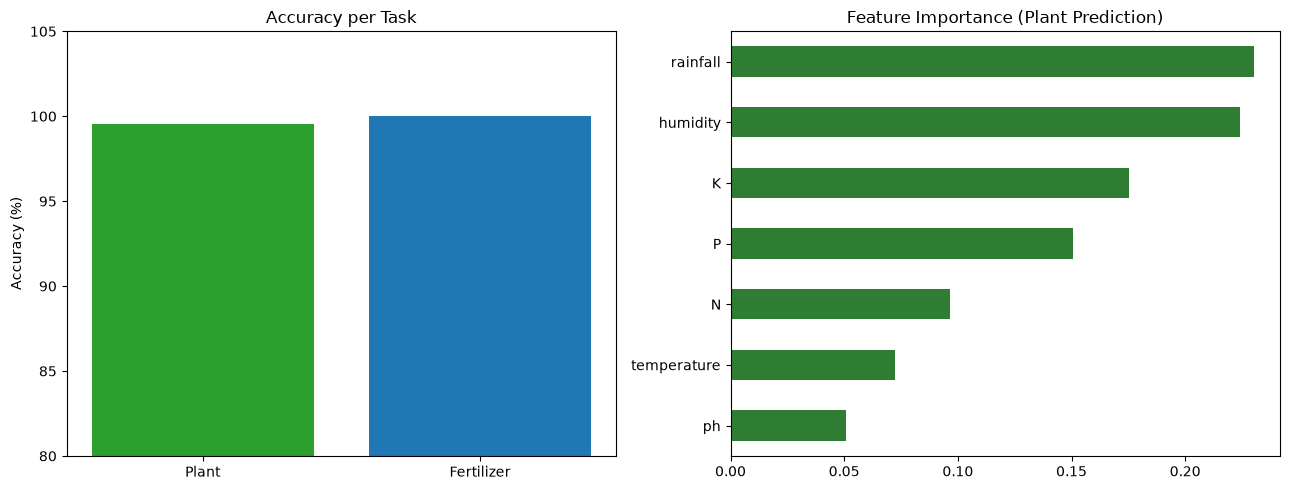

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# --- ข้อมูลที่ 1: ทำนายพืช (Plant.csv) ---
df_plant = pd.read_csv('Plant.csv')
features_plant = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X_p = df_plant[features_plant]
y_p = df_plant['label']
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(X_p, y_p, test_size=0.2, random_state=42, stratify=y_p)

model_plant = RandomForestClassifier(n_estimators=100, random_state=42)
model_plant.fit(X_p_train, y_p_train)
acc_plant = accuracy_score(y_p_test, model_plant.predict(X_p_test)) * 100

# --- ข้อมูลที่ 2: ทำนายปุ๋ย (Fertilizer.csv) ---
df_fert = pd.read_csv('Fertilizer.csv')
num_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
cat_cols = ['label']
X_f = df_fert[num_cols + cat_cols]
y_f = df_fert['fertilizer']
X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(X_f, y_f, test_size=0.2, random_state=42, stratify=y_f)

preprocessor = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='passthrough')
model_fert = Pipeline([('prep', preprocessor), ('rf', RandomForestClassifier(n_estimators=100, random_state=42))])
model_fert.fit(X_f_train, y_f_train)
acc_fert = accuracy_score(y_f_test, model_fert.predict(X_f_test)) * 100

print(f"Random Forest - Plant Accuracy: {acc_plant:.2f}%, Fertilizer Accuracy: {acc_fert:.2f}%")

# --- พล็อตกราฟเปรียบเทียบทั้ง 2 งาน ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(['Plant', 'Fertilizer'], [acc_plant, acc_fert], color=['#2ca02c', '#1f77b4'])
axes[0].set_ylim(80, 105)
axes[0].set_title('Accuracy per Task')
axes[0].set_ylabel('Accuracy (%)')

feat_imp = pd.Series(model_plant.feature_importances_, index=features_plant).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='#2e7d32')
axes[1].set_title('Feature Importance (Plant Prediction)')
plt.tight_layout()
plt.show()